# Mineração de Dados - Steam (Idiomas, Gêneros, Publishers e Preços)

## Problema investigado
Analisar acessibilidade de idioma na Steam com foco em PT-BR:
- Quais gêneros têm maior presença de jogos com suporte a Portuguese - Brazil
- Como PT-BR se compara com outros idiomas
- Quais publishers mais oferecem acessibilidade linguística
- Se existe relação entre suporte a PT-BR e preço, considerando moedas diferentes

## Tipo de tarefa e target
- **Tarefa principal de negócio:** análise exploratória (EDA)
- **Tarefa de modelagem para a disciplina:** classificação
- **Atributo alvo (target):** `tem_ptbr` (1 se o jogo suporta PT-BR, 0 caso contrário)

In [1]:
# Instale dependências (rode uma vez por ambiente)
%pip install -q kagglehub pandas numpy matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix
)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)
sns.set_theme(style="whitegrid")

In [2]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Carrega dataset da Steam (ajuste o file_path se o nome mudar)
file_path = "games_march2025_cleaned.csv"
df_raw = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "artermiloff/steam-games-dataset",
    file_path,
 )

df_raw = df_raw.copy()
print(f"Shape bruto: {df_raw.shape}")
display(df_raw.head(3))

# Funções auxiliares para mapear nomes de colunas comuns
def pick_col(df, candidates):
    cols_lower = {c.lower(): c for c in df.columns}
    for cand in candidates:
        if cand.lower() in cols_lower:
            return cols_lower[cand.lower()]
    for c in df.columns:
        c_norm = c.lower().replace(" ", "_")
        if c_norm in [x.lower().replace(" ", "_") for x in candidates]:
            return c
    return None

COL = {
    "appid": pick_col(df_raw, ["appid", "app_id", "steam_appid", "id"]),
    "name": pick_col(df_raw, ["name", "game", "title"]),
    "genres": pick_col(df_raw, ["genres", "genre"]),
    "languages": pick_col(df_raw, ["supported_languages", "languages", "supported language"]),
    "publishers": pick_col(df_raw, ["publishers", "publisher"]),
    "developers": pick_col(df_raw, ["developers", "developer"]),
    "price": pick_col(df_raw, ["price_final", "price", "final_price", "usd_price", "price_usd"]),
    "currency": pick_col(df_raw, ["pricecurrency", "currency", "price_currency"]),
    "audio": pick_col(df_raw, ["full_audio_languages", "audio_languages", "audio"]),
}

print("Mapeamento de colunas:")
for k, v in COL.items():
    print(f"{k:>10}: {v}")

if COL["appid"] is None:
    df_raw = df_raw.reset_index().rename(columns={"index": "appid"})
    COL["appid"] = "appid"
    print("appid não encontrado; criado a partir do índice.")

100%|██████████| 447M/447M [00:15<00:00, 29.3MB/s] 


Shape bruto: (89618, 47)


,appid,name,release_date,required_age,price,dlc_count,detailed_description,about_the_game,short_description,reviews,header_image,website,support_url,support_email,windows,mac,linux,metacritic_score,metacritic_url,achievements,recommendations,notes,supported_languages,full_audio_languages,packages,developers,publishers,categories,genres,screenshots,movies,user_score,score_rank,positive,negative,estimated_owners,average_playtime_forever,average_playtime_2weeks,median_playtime_forever,median_playtime_2weeks,discount,peak_ccu,tags,pct_pos_total,num_reviews_total,pct_pos_recent,num_reviews_recent
0,730,Counter-Strike 2,2012-08-21,0,0.0,1,"For over two decades, Counter-Strike has offer...","For over two decades, Counter-Strike has offer...","For over two decades, Counter-Strike has offer...",NaN,https://shared.akamai.steamstatic.com/store_it...,http://counter-strike.net/,NaN,NaN,True,False,True,0,NaN,1,4401572,Includes intense violence and blood.,"['Czech', 'Danish', 'Dutch', 'English', 'Finni...","['English', 'Indonesian']","[{'title': 'Buy Counter-Strike 2', 'descriptio...",['Valve'],['Valve'],"['Multi-player', 'Cross-Platform Multiplayer',...","['Action', 'Free To Play']",['https://shared.akamai.steamstatic.com/store_...,['http://video.akamai.steamstatic.com/store_tr...,0,NaN,7480813,1135108,100000000 - 200000000,33189,879,5174,350,0,1212356,"{'FPS': 90857, 'Shooter': 65397, 'Multiplayer'...",86,8632939,82,96473
1,578080,PUBG: BATTLEGROUNDS,2017-12-21,0,0.0,0,"LAND, LOOT, SURVIVE! Play PUBG: BATTLEGROUNDS ...","LAND, LOOT, SURVIVE! Play PUBG: BATTLEGROUNDS ...",Play PUBG: BATTLEGROUNDS for free. Land on str...,NaN,https://shared.akamai.steamstatic.com/store_it...,https://www.pubg.com,https://support.pubg.com/hc/en-us,NaN,True,False,False,0,NaN,37,1732007,NaN,"['English', 'Korean', 'Simplified Chinese', 'F...",[],[],['PUBG Corporation'],"['KRAFTON, Inc.']","['Multi-player', 'PvP', 'Online PvP', 'Stats',...","['Action', 'Adventure', 'Massively Multiplayer...",['https://shared.akamai.steamstatic.com/store_...,[],0,NaN,1487960,1024436,50000000 - 100000000,0,0,0,0,0,616738,"{'Survival': 14838, 'Shooter': 12727, 'Battle ...",59,2513842,68,16720
2,570,Dota 2,2013-07-09,0,0.0,2,"The most-played game on Steam. Every day, mill...","The most-played game on Steam. Every day, mill...","Every day, millions of players worldwide enter...",“A modern multiplayer masterpiece.” 9.5/10 – D...,https://shared.akamai.steamstatic.com/store_it...,http://www.dota2.com/,NaN,NaN,True,True,True,90,https://www.metacritic.com/game/pc/dota-2?ftag...,0,14337,"Dota 2 includes fantasy violence, use of alcoh...","['Bulgarian', 'Czech', 'Danish', 'Dutch', 'Eng...","['English', 'Korean', 'Simplified Chinese', 'V...","[{'title': 'Buy Dota 2', 'description': '', 's...",['Valve'],['Valve'],"['Multi-player', 'Co-op', 'Steam Trading Cards...","['Action', 'Strategy', 'Free To Play']",['https://shared.akamai.steamstatic.com/store_...,['http://video.akamai.steamstatic.com/store_tr...,0,NaN,1998462,451338,200000000 - 500000000,43031,1536,898,892,0,555977,"{'Free to Play': 59933, 'MOBA': 20158, 'Multip...",81,2452595,80,29366


Mapeamento de colunas:
     appid: appid
      name: name
    genres: genres
 languages: supported_languages
publishers: publishers
developers: developers
     price: price
  currency: None
     audio: full_audio_languages


In [3]:
# Etapa 1: inspeção inicial
print(f"Instâncias: {df_raw.shape[0]} | Atributos: {df_raw.shape[1]}")
display(df_raw.head(10))

print("\nTipos de dados:")
display(df_raw.dtypes.sort_index())

missing = df_raw.isna().sum().sort_values(ascending=False)
missing = missing[missing > 0]
print("\nValores ausentes por coluna (somente > 0):")
display(missing.to_frame("n_missing"))

Instâncias: 89618 | Atributos: 47


,appid,name,release_date,required_age,price,dlc_count,detailed_description,about_the_game,short_description,reviews,header_image,website,support_url,support_email,windows,mac,linux,metacritic_score,metacritic_url,achievements,recommendations,notes,supported_languages,full_audio_languages,packages,developers,publishers,categories,genres,screenshots,movies,user_score,score_rank,positive,negative,estimated_owners,average_playtime_forever,average_playtime_2weeks,median_playtime_forever,median_playtime_2weeks,discount,peak_ccu,tags,pct_pos_total,num_reviews_total,pct_pos_recent,num_reviews_recent
0,730,Counter-Strike 2,2012-08-21,0,0.00,1,"For over two decades, Counter-Strike has offer...","For over two decades, Counter-Strike has offer...","For over two decades, Counter-Strike has offer...",NaN,https://shared.akamai.steamstatic.com/store_it...,http://counter-strike.net/,NaN,NaN,True,False,True,0,NaN,1,4401572,Includes intense violence and blood.,"['Czech', 'Danish', 'Dutch', 'English', 'Finni...","['English', 'Indonesian']","[{'title': 'Buy Counter-Strike 2', 'descriptio...",['Valve'],['Valve'],"['Multi-player', 'Cross-Platform Multiplayer',...","['Action', 'Free To Play']",['https://shared.akamai.steamstatic.com/store_...,['http://video.akamai.steamstatic.com/store_tr...,0,NaN,7480813,1135108,100000000 - 200000000,33189,879,5174,350,0,1212356,"{'FPS': 90857, 'Shooter': 65397, 'Multiplayer'...",86,8632939,82,96473
1,578080,PUBG: BATTLEGROUNDS,2017-12-21,0,0.00,0,"LAND, LOOT, SURVIVE! Play PUBG: BATTLEGROUNDS ...","LAND, LOOT, SURVIVE! Play PUBG: BATTLEGROUNDS ...",Play PUBG: BATTLEGROUNDS for free. Land on str...,NaN,https://shared.akamai.steamstatic.com/store_it...,https://www.pubg.com,https://support.pubg.com/hc/en-us,NaN,True,False,False,0,NaN,37,1732007,NaN,"['English', 'Korean', 'Simplified Chinese', 'F...",[],[],['PUBG Corporation'],"['KRAFTON, Inc.']","['Multi-player', 'PvP', 'Online PvP', 'Stats',...","['Action', 'Adventure', 'Massively Multiplayer...",['https://shared.akamai.steamstatic.com/store_...,[],0,NaN,1487960,1024436,50000000 - 100000000,0,0,0,0,0,616738,"{'Survival': 14838, 'Shooter': 12727, 'Battle ...",59,2513842,68,16720
2,570,Dota 2,2013-07-09,0,0.00,2,"The most-played game on Steam. Every day, mill...","The most-played game on Steam. Every day, mill...","Every day, millions of players worldwide enter...",“A modern multiplayer masterpiece.” 9.5/10 – D...,https://shared.akamai.steamstatic.com/store_it...,http://www.dota2.com/,NaN,NaN,True,True,True,90,https://www.metacritic.com/game/pc/dota-2?ftag...,0,14337,"Dota 2 includes fantasy violence, use of alcoh...","['Bulgarian', 'Czech', 'Danish', 'Dutch', 'Eng...","['English', 'Korean', 'Simplified Chinese', 'V...","[{'title': 'Buy Dota 2', 'description': '', 's...",['Valve'],['Valve'],"['Multi-player', 'Co-op', 'Steam Trading Cards...","['Action', 'Strategy', 'Free To Play']",['https://shared.akamai.steamstatic.com/store_...,['http://video.akamai.steamstatic.com/store_tr...,0,NaN,1998462,451338,200000000 - 500000000,43031,1536,898,892,0,555977,"{'Free to Play': 59933, 'MOBA': 20158, 'Multip...",81,2452595,80,29366
3,271590,Grand Theft Auto V Legacy,2015-04-13,17,0.00,0,"When a young street hustler, a retired bank ro...","When a young street hustler, a retired bank ro...",Grand Theft Auto V for PC offers players the o...,NaN,https://shared.akamai.steamstatic.com/store_it...,https://www.rockstargames.com/V/,https://support.rockstargames.com,NaN,True,False,False,96,https://www.metacritic.com/game/pc/grand-theft...,77,1803063,NaN,"['English', 'French', 'Italian', 'German', 'Sp...","['English', 'Spanish - Latin America']","[{'title': 'Buy Shark Cash Cards', 'descriptio...",['Rockstar North'],['Rockstar Games'],"['Single-player', 'Multi-player', 'PvP', 'Onli...","['Action', 'Adventure']",['https://shared.akamai.steamstatic.com/store_...,['http://video.akamai.steamstatic.com/store_tr...,0,NaN,1719950,250012,50000000 - 100000000,19323,771,7101,74,0,117698,"{'Open World':


Tipos de dados:


about_the_game                  str
achievements                  int64
appid                         int64
average_playtime_2weeks       int64
average_playtime_forever      int64
categories                      str
detailed_description            str
developers                      str
discount                      int64
dlc_count                     int64
estimated_owners                str
full_audio_languages            str
genres                          str
header_image                    str
linux                          bool
mac                            bool
median_playtime_2weeks        int64
median_playtime_forever       int64
metacritic_score              int64
metacritic_url                  str
movies                          str
name                            str
negative                      int64
notes                           str
num_reviews_recent            int64
num_reviews_total             int64
packages                        str
pct_pos_recent              


Valores ausentes por coluna (somente > 0):


,n_missing
score_rank,89579
metacritic_url,86071
reviews,79217
notes,72975
website,48504
support_url,45508
support_email,10820
about_the_game,220
detailed_description,197
short_description,120


In [6]:
# Etapa 2 e 3: preparação para EDA
import ast

df = df_raw.copy()

def split_clean_series(series):
    def parse_one(value):
        if pd.isna(value):
            return []
        text = str(value).strip()
        if not text or text.lower() == "nan":
            return []

        # Tenta interpretar listas serializadas, ex.: "['Action', 'Indie']"
        if text.startswith("[") and text.endswith("]"):
            try:
                parsed = ast.literal_eval(text)
                if isinstance(parsed, list):
                    return [str(x).strip() for x in parsed if str(x).strip()]
            except Exception:
                pass

        text = text.replace(";", ",")
        parts = [p.strip() for p in text.split(",") if p.strip()]
        cleaned = []
        for p in parts:
            p2 = p.strip("[]'").strip('"').strip()
            if p2 and p2.lower() != "nan":
                cleaned.append(p2)
        return cleaned

    return series.apply(parse_one)

if COL["languages"] is not None:
    df["lang_list"] = split_clean_series(df[COL["languages"]])
else:
    df["lang_list"] = [[] for _ in range(len(df))]

if COL["genres"] is not None:
    df["genre_list"] = split_clean_series(df[COL["genres"]])
else:
    df["genre_list"] = [[] for _ in range(len(df))]

if COL["publishers"] is not None:
    df["publisher_list"] = split_clean_series(df[COL["publishers"]])
else:
    df["publisher_list"] = [[] for _ in range(len(df))]

if COL["audio"] is not None:
    df["audio_list"] = split_clean_series(df[COL["audio"]])
else:
    df["audio_list"] = [[] for _ in range(len(df))]

df["tem_ptbr"] = df["lang_list"].apply(
    lambda lst: any("portuguese" in x.lower() and "brazil" in x.lower() for x in lst)
).astype(int)

df["num_languages"] = df["lang_list"].apply(len)
df["num_genres"] = df["genre_list"].apply(len)

display(df[[COL["appid"], COL["name"] if COL["name"] else COL["appid"], "num_languages", "num_genres", "tem_ptbr"]].head(10))

,appid,name,num_languages,num_genres,tem_ptbr
0,730,Counter-Strike 2,29,2,1
1,578080,PUBG: BATTLEGROUNDS,17,4,1
2,570,Dota 2,28,3,1
3,271590,Grand Theft Auto V Legacy,13,2,1
4,359550,Tom Clancy's Rainbow Six® Siege,16,1,1
5,440,Team Fortress 2,27,2,1
6,105600,Terraria,9,4,1
7,252490,Rust,25,5,1
8,4000,Garry's Mod,25,3,1
9,1172470,Apex Legends™,14,3,1


,qtd_jogos_ptbr
genre_list,
Indie,9248
Casual,6034
Action,5746
Adventure,5406
Simulation,3170
Strategy,2864
RPG,2138
Free To Play,1015
Early Access,916


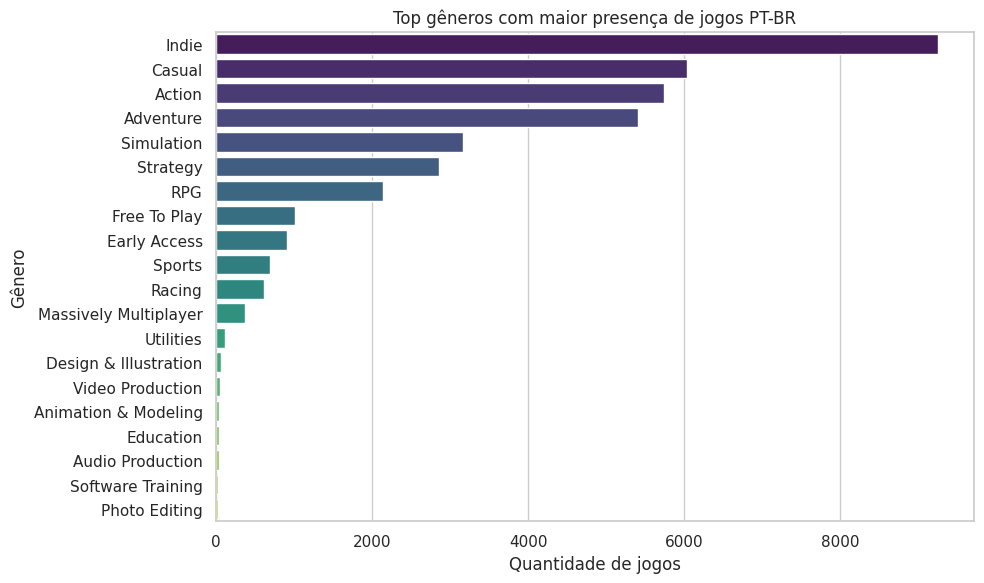

In [7]:
# Quais gêneros têm maior presença em jogos com PT-BR?
df_pt = df[df["tem_ptbr"] == 1].copy()

df_pt_gen = df_pt[[COL["appid"], "genre_list"]].explode("genre_list")
df_pt_gen = df_pt_gen[df_pt_gen["genre_list"].notna() & (df_pt_gen["genre_list"] != "")]

top_genres_pt = (
    df_pt_gen.groupby("genre_list")[COL["appid"]]
    .nunique()
    .sort_values(ascending=False)
    .head(20)
    .rename("qtd_jogos_ptbr")
)

display(top_genres_pt.to_frame())

plt.figure(figsize=(10, 6))
sns.barplot(x=top_genres_pt.values, y=top_genres_pt.index, palette="viridis")
plt.title("Top gêneros com maior presença de jogos PT-BR")
plt.xlabel("Quantidade de jogos")
plt.ylabel("Gênero")
plt.tight_layout()
plt.show()

,qtd_jogos
lang_list,
English,85561
Simplified Chinese,24735
German,22447
French,22147
Japanese,21069
Russian,20757
Spanish - Spain,20682
Italian,15392
Korean,13787


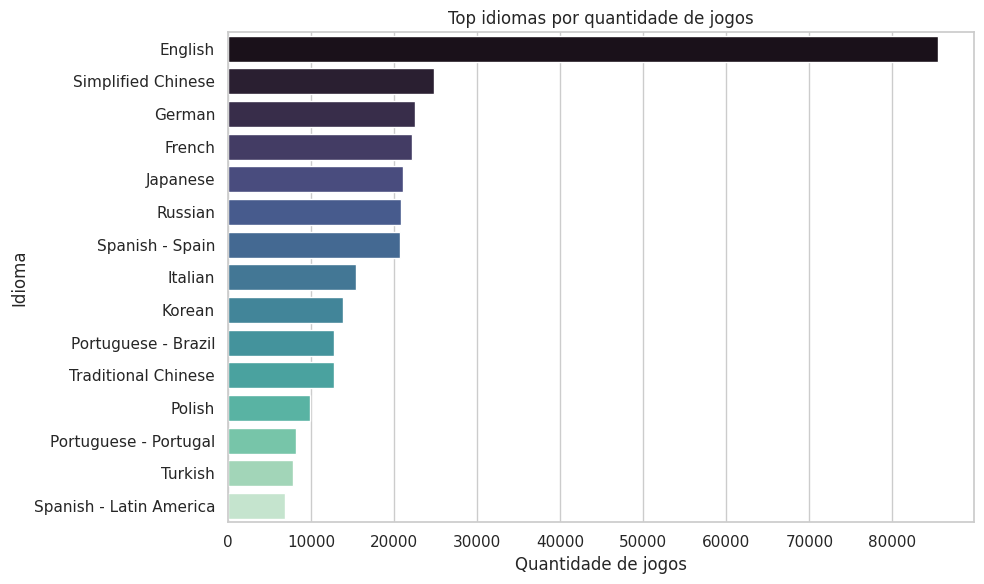


Top idiomas de áudio (dublagem):


,qtd_jogos_audio
audio_list,
English,35826
Simplified Chinese,6351
Japanese,5602
Russian,5311
German,4789
French,4489
Spanish - Spain,4450
Traditional Chinese,3824
Korean,3280


In [8]:
# Comparação com outros idiomas: quais têm mais jogos com suporte
df_lang = df[[COL["appid"], "lang_list"]].explode("lang_list")
df_lang = df_lang[df_lang["lang_list"].notna() & (df_lang["lang_list"] != "")].drop_duplicates()

ranking_idiomas = (
    df_lang.groupby("lang_list")[COL["appid"]]
    .nunique()
    .sort_values(ascending=False)
    .rename("qtd_jogos")
)

display(ranking_idiomas.head(20).to_frame())

plt.figure(figsize=(10, 6))
top_langs = ranking_idiomas.head(15)
sns.barplot(x=top_langs.values, y=top_langs.index, palette="mako")
plt.title("Top idiomas por quantidade de jogos")
plt.xlabel("Quantidade de jogos")
plt.ylabel("Idioma")
plt.tight_layout()
plt.show()

# Se houver informação de áudio, comparamos também dublagem
if COL["audio"] is not None:
    df_audio = df[[COL["appid"], "audio_list"]].explode("audio_list")
    df_audio = df_audio[df_audio["audio_list"].notna() & (df_audio["audio_list"] != "")].drop_duplicates()
    ranking_audio = (
        df_audio.groupby("audio_list")[COL["appid"]]
        .nunique()
        .sort_values(ascending=False)
        .rename("qtd_jogos_audio")
    )
    print("\nTop idiomas de áudio (dublagem):")
    display(ranking_audio.head(15).to_frame())
else:
    print("Este dataset não possui coluna explícita de áudio/dublagem.")
    print("A análise de idiomas usa suporte geral (normalmente interface/legenda).")

In [10]:
# Publishers com maior acessibilidade linguística
df_pub = df[[COL["appid"], "publisher_list", "num_languages", "tem_ptbr"]].explode("publisher_list")
df_pub = df_pub[df_pub["publisher_list"].notna() & (df_pub["publisher_list"] != "")].copy()

pub_stats = (
    df_pub.groupby("publisher_list").agg(
        jogos_total=(COL["appid"], "nunique"),
        jogos_com_ptbr=("tem_ptbr", "sum"),
        media_idiomas_por_jogo=("num_languages", "mean"),
    )
).sort_values("jogos_com_ptbr", ascending=False)

print("Top publishers por quantidade de jogos com PT-BR:")
display(pub_stats.sort_values("jogos_com_ptbr", ascending=False).head(20))

# Evita viés de publishers com pouquíssimos jogos
MIN_GAMES = 5
pub_lang_robusto = pub_stats[pub_stats["jogos_total"] >= MIN_GAMES] \
    .sort_values("media_idiomas_por_jogo", ascending=False) \
    .head(20)

print(f"Top publishers por média de idiomas por jogo (mínimo de {MIN_GAMES} jogos):")
display(pub_lang_robusto)

Top publishers por quantidade de jogos com PT-BR:


,jogos_total,jogos_com_ptbr,media_idiomas_por_jogo
publisher_list,,,
Hede,155,141,77.400000
PlayWay S.A.,156,80,12.871795
Blender Games,76,75,100.684211
Ubisoft,105,73,11.580952
Devolver Digital,116,71,7.715517
Cute Hannah's Games,62,62,103.000000
tinyBuild,85,57,7.917647
Nacon,96,51,9.104167
Electronic Arts,106,46,8.990566


Top publishers por média de idiomas por jogo (mínimo de 5 jogos):


,jogos_total,jogos_com_ptbr,media_idiomas_por_jogo
publisher_list,,,
Catnip Studio,7,7,103.000000
Gigantum Games,6,6,103.000000
KazakovStudios,6,6,103.000000
Quantum Quiver Games,26,26,103.000000
Cute Hannah's Games,62,62,103.000000
Azerbaijan Technology,12,12,103.000000
khukhrovr,22,22,103.000000
Walter Machado,21,21,103.000000
WGI GAMING,5,5,103.000000


## Etapa 2 - Análise exploratória (describe, variabilidade, outliers e correlações)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
appid,89618.0,NaN,NaN,NaN,1656903.958357,916838.982016,20.0,855052.5,1524730.0,2430852.5,3542350.0
name,89618,88899,Alone,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
release_date,89618,4459,2024-10-31,141,NaN,NaN,NaN,NaN,NaN,NaN,NaN
required_age,89618.0,NaN,NaN,NaN,0.183624,1.725594,-1.0,0.0,0.0,0.0,21.0
price,89618.0,NaN,NaN,NaN,7.309623,13.331073,0.0,0.99,4.99,9.99,999.98
dlc_count,89618.0,NaN,NaN,NaN,0.595583,15.35192,0.0,0.0,0.0,0.0,3427.0
detailed_description,89421,89075,Help the beautiful girls to immerse themselves...,58,NaN,NaN,NaN,NaN,NaN,NaN,NaN
about_the_game,89398,89040,Help the beautiful girls to immerse themselves...,58,NaN,NaN,NaN,NaN,NaN,NaN,NaN
short_description,89498,88586,Find the objects that are hidden on the map.,50,NaN,NaN,NaN,NaN,NaN,NaN,NaN
reviews,10401,10291,“ ” Read more on PC Gamer,21,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Atributos numéricos com maior variabilidade:


,std
appid,916838.982016
num_reviews_total,35423.696776
positive,31814.411404
recommendations,22048.147658
median_playtime_forever,8806.711196
average_playtime_forever,6814.747948
negative,6114.313689
peak_ccu,5717.544398
num_reviews_recent,444.277307
median_playtime_2weeks,189.591095


Colunas com mais outliers (IQR):


,qtd_outliers
positive,15039
negative,14344
num_reviews_total,14333
num_languages,13281
achievements,5636
price,4146
num_genres,467
required_age,0
user_score,0
recommendations,0


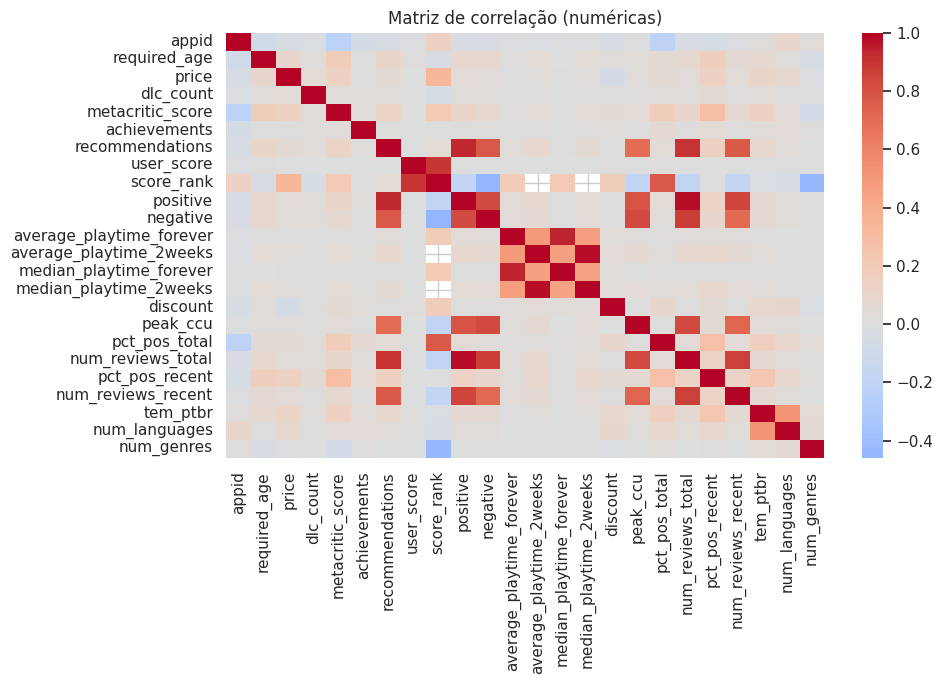

In [11]:
display(df.describe(include="all").T.head(30))

# Variabilidade numérica
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if num_cols:
    variabilidade = df[num_cols].std(numeric_only=True).sort_values(ascending=False)
    print("Atributos numéricos com maior variabilidade:")
    display(variabilidade.head(15).to_frame("std"))

# Outliers via IQR (colunas numéricas)
def outlier_count_iqr(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    if pd.isna(iqr) or iqr == 0:
        return 0
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return ((series < lower) | (series > upper)).sum()

if num_cols:
    outliers = {c: outlier_count_iqr(df[c].dropna()) for c in num_cols}
    outliers = pd.Series(outliers).sort_values(ascending=False)
    print("Colunas com mais outliers (IQR):")
    display(outliers.head(15).to_frame("qtd_outliers"))

# Correlação numérica
if len(num_cols) >= 2:
    corr = df[num_cols].corr(numeric_only=True)
    plt.figure(figsize=(10, 7))
    sns.heatmap(corr, cmap="coolwarm", center=0)
    plt.title("Matriz de correlação (numéricas)")
    plt.tight_layout()
    plt.show()

## Relação entre PT-BR e preço por moeda

In [12]:
if COL["price"] is None:
    print("Nenhuma coluna de preço foi encontrada automaticamente.")
else:
    preco_col = COL["price"]
    moeda_col = COL["currency"] if COL["currency"] is not None else None

    base_preco = df[[COL["appid"], "tem_ptbr", preco_col] + ([moeda_col] if moeda_col else [])].copy()
    base_preco[preco_col] = pd.to_numeric(base_preco[preco_col], errors="coerce")
    base_preco = base_preco.dropna(subset=[preco_col])

    if moeda_col is None:
        base_preco["currency_tmp"] = "UNKNOWN"
        moeda_col = "currency_tmp"

    resumo_preco = (
        base_preco.groupby([moeda_col, "tem_ptbr"])[preco_col]
        .agg(["count", "mean", "median", "std"])
        .reset_index()
        .sort_values([moeda_col, "tem_ptbr"])
)
    display(resumo_preco.head(40))

    # Diferença percentual de preço médio (PTBR vs sem PTBR) por moeda
    piv = resumo_preco.pivot(index=moeda_col, columns="tem_ptbr", values="mean")
    if 0 in piv.columns and 1 in piv.columns:
        piv = piv.rename(columns={0: "mean_sem_ptbr", 1: "mean_com_ptbr"})
        piv["diff_pct"] = ((piv["mean_com_ptbr"] - piv["mean_sem_ptbr"]) / piv["mean_sem_ptbr"]) * 100
        display(piv.sort_values("diff_pct", ascending=False).head(20))
    else:
        print("Não há observações suficientes para comparar com/sem PT-BR em todas as moedas.")

,currency_tmp,tem_ptbr,count,mean,median,std
0,UNKNOWN,0,76841,6.752631,4.95,12.136336
1,UNKNOWN,1,12777,10.659375,4.99,18.645191


tem_ptbr,mean_sem_ptbr,mean_com_ptbr,diff_pct
currency_tmp,,,
UNKNOWN,6.752631,10.659375,57.855144


## Etapas 4, 5 e 6 - Seleção de atributos, modelagem e avaliação
Modelos treinados para prever `tem_ptbr` (classificação):
- Regressão Logística
- MLP (Rede Neural)

In [13]:
# Base de modelagem
model_df = pd.DataFrame({
    "tem_ptbr": df["tem_ptbr"].astype(int),
    "num_languages": pd.to_numeric(df["num_languages"], errors="coerce"),
    "num_genres": pd.to_numeric(df["num_genres"], errors="coerce"),
})

if COL["price"] is not None:
    model_df["price"] = pd.to_numeric(df[COL["price"]], errors="coerce")
if COL["currency"] is not None:
    model_df["currency"] = df[COL["currency"]].astype(str)

# Simplifica gênero e publisher em categorias principais para reduzir cardinalidade
def top_item(lst, default="Unknown"):
    if isinstance(lst, list) and len(lst) > 0:
        return lst[0]
    return default

model_df["main_genre"] = df["genre_list"].apply(top_item)
model_df["main_publisher"] = df["publisher_list"].apply(top_item)

# Reduz cardinalidade dos publishers (mantém top 30)
top_pubs = model_df["main_publisher"].value_counts().head(30).index
model_df["main_publisher"] = model_df["main_publisher"].where(model_df["main_publisher"].isin(top_pubs), "Other")

# Remove linhas sem target
model_df = model_df.dropna(subset=["tem_ptbr"]).copy()
display(model_df.head())
print(model_df.shape)

,tem_ptbr,num_languages,num_genres,price,main_genre,main_publisher
0,1,29,2,0.00,Action,Other
1,1,17,4,0.00,Action,Other
2,1,28,3,0.00,Action,Other
3,1,13,2,0.00,Action,Other
4,1,16,1,3.99,Action,Ubisoft


(89618, 6)


,model,acc_train,acc_test,precision_test,recall_test,f1_test,roc_auc_test
1,MLPClassifier,0.929631,0.922395,0.762873,0.661057,0.708325,0.953767
0,LogisticRegression,0.901847,0.898851,0.602317,0.854795,0.706682,0.951117


Melhor modelo por F1 de teste: MLPClassifier

Classification report:
              precision    recall  f1-score   support

           0     0.9449    0.9658    0.9552     15369
           1     0.7629    0.6611    0.7083      2555

    accuracy                         0.9224     17924
   macro avg     0.8539    0.8134    0.8318     17924
weighted avg     0.9189    0.9224    0.9200     17924



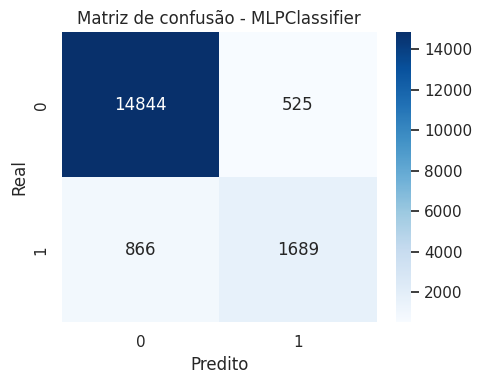

In [14]:
# Treino/teste e comparação de modelos
target = "tem_ptbr"
X = model_df.drop(columns=[target])
y = model_df[target]

num_features = X.select_dtypes(include=[np.number]).columns.tolist()
cat_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, num_features),
        ("cat", categorical_pipe, cat_features),
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

models = {
    "LogisticRegression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "MLPClassifier": MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=300, random_state=42),
}

results = []
trained = {}

for name, model in models.items():
    pipe = Pipeline(steps=[("prep", preprocess), ("model", model)])
    pipe.fit(X_train, y_train)

    pred_train = pipe.predict(X_train)
    pred_test = pipe.predict(X_test)

    if hasattr(pipe[-1], "predict_proba"):
        proba_test = pipe.predict_proba(X_test)[:, 1]
        roc = roc_auc_score(y_test, proba_test)
    else:
        roc = np.nan

    row = {
        "model": name,
        "acc_train": accuracy_score(y_train, pred_train),
        "acc_test": accuracy_score(y_test, pred_test),
        "precision_test": precision_score(y_test, pred_test, zero_division=0),
        "recall_test": recall_score(y_test, pred_test, zero_division=0),
        "f1_test": f1_score(y_test, pred_test, zero_division=0),
        "roc_auc_test": roc,
    }
    results.append(row)
    trained[name] = pipe

res_models = pd.DataFrame(results).sort_values("f1_test", ascending=False)
display(res_models)

best_model_name = res_models.iloc[0]["model"]
best_model = trained[best_model_name]
best_pred = best_model.predict(X_test)

print(f"Melhor modelo por F1 de teste: {best_model_name}")
print("\nClassification report:")
print(classification_report(y_test, best_pred, digits=4))

cm = confusion_matrix(y_test, best_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Matriz de confusão - {best_model_name}")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.tight_layout()
plt.show()

## Etapa 7 - Conclusão

Use os resultados das células acima para responder objetivamente:
1. O modelo atende ao problema proposto?
- Acredito que conseguirmos responder algumas perguntas pertinentes 
2. Quais foram as principais dificuldades (dados ausentes, nomes de colunas, cardinalidade de publishers etc.)?
- Encontrar o dataset correto que tenha os dados que podem ser entraido para reponder as perguntas 
3. O que poderia ser melhorado (mais features, tuning, validação cruzada, dados externos)?
- Validação cruzada eu acreedito e dados externos 
4. Outras abordagens possíveis: XGBoost/LightGBM, embeddings de texto para descrição, clusterização de perfis de idioma.